In [1]:
import os
import numpy as np
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from dataclasses import dataclass
from sklearn.metrics import jaccard_score, f1_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

import torchvision
import torchvision.transforms.functional as F
import torchvision.transforms.v2 as transforms

In [2]:
import pandas as pd
import random

In [3]:
@dataclass
class Config:
    image_size = (128, 128)
    batch_size = 32
    epochs = 15
    learning_rate = 0.0001
    device = "cuda" if torch.cuda.is_available() else "cpu"
    train_split = 0.8

    seed = 42
    n_workers = 2

    in_channels = 3
    out_channels = 1
    base_channels = 64
    use_batchnorm = True

    sweep_lrs_stage1 = [1e-2, 3e-3, 1e-3, 3e-4, 1e-4, 3e-5]
    fixed_batch_size = 32
    sweep_batch_sizes = [8, 16, 32]

    sweep_lrs_stage2 = []


config = Config()

In [4]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, use_batchnorm=True):
        super(DoubleConv, self).__init__()

        layers = [
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=not use_batchnorm
            )
        ]
        if use_batchnorm:
            layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.ReLU(inplace=True))

        layers.append(
            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=not use_batchnorm
            )
        )
        if use_batchnorm:
            layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.ReLU(inplace=True))

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)




class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, base_channels=64, use_batchnorm=True):
        super(UNet, self).__init__()

        # тут слои обозначить для encoder, bottleneck и decoder
        #encoder
        self.enc1 = DoubleConv(in_channels, base_channels, use_batchnorm)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.enc2 = DoubleConv(base_channels, base_channels * 2, use_batchnorm)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.enc3 = DoubleConv(base_channels * 2, base_channels * 4, use_batchnorm)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.enc4 = DoubleConv(base_channels * 4, base_channels * 8, use_batchnorm)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        #bottleneck
        self.bottleneck = DoubleConv(base_channels * 8, base_channels * 16, use_batchnorm)

        #decoder
        self.up4 = nn.ConvTranspose2d(base_channels * 16, base_channels * 8, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(base_channels * 16, base_channels * 8, use_batchnorm)

        self.up3 = nn.ConvTranspose2d(base_channels * 8, base_channels * 4, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(base_channels * 8, base_channels * 4, use_batchnorm)

        self.up2 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(base_channels * 4, base_channels * 2, use_batchnorm)

        self.up1 = nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(base_channels * 2, base_channels, use_batchnorm)

        self.final = nn.Conv2d(base_channels, out_channels, kernel_size=1)


    def forward(self, x):
        # encoder path
        e1 = self.enc1(x)                # [B, 64, 128, 128]
        e2 = self.enc2(self.pool1(e1))   # [B, 128, 64, 64]
        e3 = self.enc3(self.pool2(e2))   # [B, 256, 32, 32]
        e4 = self.enc4(self.pool3(e3))   # [B, 512, 16, 16]

        # bottleneck
        b = self.bottleneck(self.pool4(e4))  # [B, 1024, 8, 8]

        # decoder path + skip connections
        d4 = self.up4(b)                # [B, 512, 16, 16]
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)               # [B, 256, 32, 32]
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)               # [B, 128, 64, 64]
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)               # [B, 64, 128, 128]
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        logits = self.final(d1)         # [B, 1, 128, 128]
        return logits



In [5]:
class PetDataset(Dataset):
    def __init__(self, root, image_size=(128, 128), split='trainval', transform=None):
        self.root = root
        self.image_size = image_size
        self.transform = transform
        self.dataset = torchvision.datasets.OxfordIIITPet(
            root=root,
            split=split,
            target_types='segmentation',
            download=True
        )

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]

        mask = np.array(mask)
        mask = (mask > 1).astype(np.uint8)
        mask = Image.fromarray(mask)

        if self.transform:
            image = self.transform(image)

        mask = mask.resize(self.image_size, Image.NEAREST)
        mask = F.pil_to_tensor(mask).float()

        return image, mask

In [6]:
class Trainer:
    def __init__(self, config):
        self.config = config

        self.transform = transforms.Compose([
            transforms.Resize(config.image_size),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.5, 0.5, 0.5],
                std=[0.5, 0.5, 0.5]
            )
        ])

        self.model = UNet(
            in_channels=config.in_channels,
            out_channels=config.out_channels,
            base_channels=config.base_channels,
            use_batchnorm=config.use_batchnorm
        ).to(config.device)

        self.criterion = nn.BCEWithLogitsLoss()
        self.optimizer = optim.Adam(
            self.model.parameters(),
            lr=config.learning_rate
        )

        self.best_val_iou = -1.0
        self.best_state_dict = None

        self.setup_dataloader()

    def setup_dataloader(self):
        dataset = PetDataset(
            root="./data",
            image_size=self.config.image_size,
            split="trainval",
            transform=self.transform
        )

        train_size = int(self.config.train_split * len(dataset))
        val_size = len(dataset) - train_size

        generator = torch.Generator().manual_seed(self.config.seed)
        train_dataset, val_dataset = random_split(
            dataset,
            [train_size, val_size],
            generator=generator
        )

        self.test_dataset = PetDataset(
            root="./data",
            image_size=self.config.image_size,
            split="test",
            transform=self.transform
        )

        self.train_dataloader = DataLoader(
            train_dataset,
            batch_size=self.config.batch_size,
            shuffle=True,
            num_workers=self.config.n_workers
        )

        self.val_dataloader = DataLoader(
            val_dataset,
            batch_size=self.config.batch_size,
            shuffle=False,
            num_workers=self.config.n_workers
        )

        self.test_dataloader = DataLoader(
            self.test_dataset,
            batch_size=self.config.batch_size,
            shuffle=False,
            num_workers=self.config.n_workers
        )

    def run(self):
        history = {
            "train_loss": [],
            "val_loss": [],
            "val_iou": [],
            "val_f1": []
        }

        for epoch in range(self.config.epochs):
            train_loss = self.train_one_epoch()
            val_loss, val_iou, val_f1 = self.validate()

            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss)
            history["val_iou"].append(val_iou)
            history["val_f1"].append(val_f1)

            if val_iou > self.best_val_iou:
                self.best_val_iou = val_iou
                self.best_state_dict = {
                    k: v.detach().cpu().clone()
                    for k, v in self.model.state_dict().items()
                }

            print(
                f"Epoch {epoch + 1}/{self.config.epochs} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Val Loss: {val_loss:.4f} | "
                f"Val IoU: {val_iou:.4f} | "
                f"Val F1: {val_f1:.4f}"
            )

        if self.best_state_dict is not None:
            self.model.load_state_dict(self.best_state_dict)

        print("Testing best checkpoint...")
        test_loss, test_iou, test_f1 = self.test()

        history["test_loss"] = test_loss
        history["test_iou"] = test_iou
        history["test_f1"] = test_f1
        history["best_val_iou"] = self.best_val_iou

        print(
            f"Test Loss: {test_loss:.4f} | "
            f"Test IoU: {test_iou:.4f} | "
            f"Test F1: {test_f1:.4f}"
        )

        return history

    def train_one_epoch(self):
        self.model.train()
        epoch_loss = 0.0

        for images, masks in tqdm(self.train_dataloader):
            images = images.to(self.config.device)
            masks = masks.to(self.config.device)

            self.optimizer.zero_grad()

            outputs = self.model(images)
            loss = self.criterion(outputs, masks)

            loss.backward()
            self.optimizer.step()

            epoch_loss += loss.item()

        return epoch_loss / len(self.train_dataloader)

    def validate(self):
        self.model.eval()
        val_loss = 0.0
        iou_scores = []
        f1_scores = []

        with torch.no_grad():
            for images, masks in tqdm(self.val_dataloader):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                val_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs) > 0.5).squeeze(1).cpu().numpy().astype(np.uint8)
                true_masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(
                        jaccard_score(
                            true_masks[i].flatten(),
                            pred_masks[i].flatten(),
                            average="binary"
                        )
                    )
                    f1_scores.append(
                        f1_score(
                            true_masks[i].flatten(),
                            pred_masks[i].flatten(),
                            average="binary"
                        )
                    )

        return (
            val_loss / len(self.val_dataloader),
            np.mean(iou_scores),
            np.mean(f1_scores)
        )

    def test(self):
        self.model.eval()
        test_loss = 0.0
        iou_scores = []
        f1_scores = []

        with torch.no_grad():
            for images, masks in tqdm(self.test_dataloader):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                test_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs) > 0.5).squeeze(1).cpu().numpy().astype(np.uint8)
                true_masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(
                        jaccard_score(
                            true_masks[i].flatten(),
                            pred_masks[i].flatten(),
                            average="binary",
                            zero_division=1
                        )
                    )
                    f1_scores.append(
                        f1_score(
                            true_masks[i].flatten(),
                            pred_masks[i].flatten(),
                            average="binary",
                            zero_division=1
                        )
                    )

        return (
            test_loss / len(self.test_dataloader),
            np.mean(iou_scores),
            np.mean(f1_scores)
        )

    def inference_and_plot_samples(self, n_samples=3):
        self.model.eval()

        mean = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)
        std = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)

        with torch.no_grad():
            fig, axes = plt.subplots(n_samples, 3, figsize=(10, 3 * n_samples))

            if n_samples == 1:
                axes = np.expand_dims(axes, axis=0)

            for i in range(n_samples):
                image, mask = self.test_dataset[i]
                image_tensor = image.unsqueeze(0).to(self.config.device)

                output = self.model(image_tensor)
                output = (torch.sigmoid(output) > 0.5).float().squeeze().cpu().numpy()

                image_to_show = image.cpu() * std + mean
                image_to_show = image_to_show.permute(1, 2, 0).numpy()

                axes[i, 0].imshow(image_to_show)
                axes[i, 0].set_title("Image")
                axes[i, 0].axis("off")

                axes[i, 1].imshow(mask.squeeze().cpu().numpy(), cmap="gray")
                axes[i, 1].set_title("Ground Truth")
                axes[i, 1].axis("off")

                axes[i, 2].imshow(output, cmap="gray")
                axes[i, 2].set_title("Predicted Mask")
                axes[i, 2].axis("off")

            plt.tight_layout()
            plt.show()

In [7]:
trainer = Trainer(config)

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 792M/792M [00:19<00:00, 40.3MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 17.8MB/s]


In [8]:
history = trainer.run()

100%|██████████| 23/23 [00:07<00:00,  3.20it/s]


Epoch 1/15 | Train Loss: 0.4396 | Val Loss: 0.3808 | Val IoU: 0.7909 | Val F1: 0.8776


100%|██████████| 23/23 [00:07<00:00,  3.18it/s]


Epoch 2/15 | Train Loss: 0.3209 | Val Loss: 0.2995 | Val IoU: 0.8381 | Val F1: 0.9074


100%|██████████| 23/23 [00:07<00:00,  3.21it/s]


...

Epoch 14/15 | Train Loss: 0.1068 | Val Loss: 0.1878 | Val IoU: 0.8964 | Val F1: 0.9425


100%|██████████| 23/23 [00:07<00:00,  3.18it/s]


Epoch 15/15 | Train Loss: 0.0999 | Val Loss: 0.2120 | Val IoU: 0.8875 | Val F1: 0.9367
Testing best checkpoint...


100%|██████████| 115/115 [00:34<00:00,  3.29it/s]

Test Loss: 0.2018 | Test IoU: 0.8874 | Test F1: 0.9362


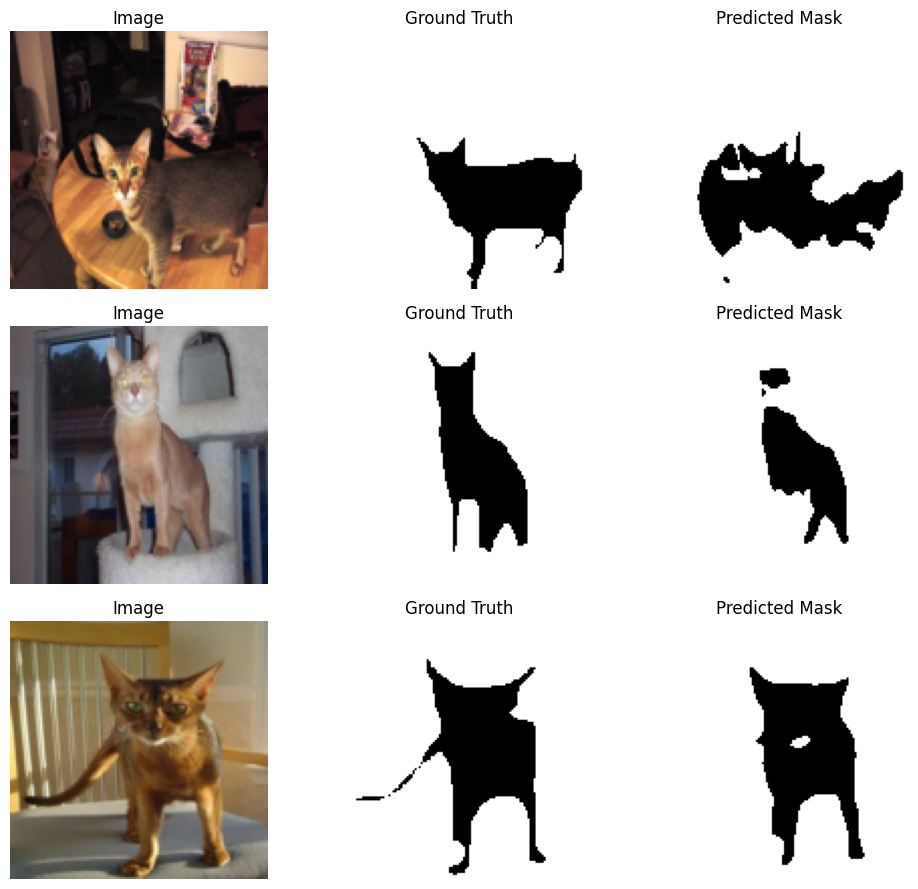

In [9]:
trainer.inference_and_plot_samples(n_samples=3)

In [10]:
import copy
import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


def build_cfg(base_cfg, **kwargs):
    cfg = copy.deepcopy(base_cfg)
    for k, v in kwargs.items():
        setattr(cfg, k, v)
    return cfg


def plot_dataset_examples(config, n_samples=3):
    display_transform = transforms.Compose([
        transforms.Resize(config.image_size),
        transforms.ToTensor()
    ])

    dataset = PetDataset(
        root="./data",
        image_size=config.image_size,
        split="trainval",
        transform=display_transform
    )

    fig, axes = plt.subplots(n_samples, 2, figsize=(8, 3 * n_samples))

    if n_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(n_samples):
        image, mask = dataset[i]

        axes[i, 0].imshow(image.permute(1, 2, 0).numpy())
        axes[i, 0].set_title("Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(mask.squeeze().numpy(), cmap="gray")
        axes[i, 1].set_title("Ground Truth Mask")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()




In [11]:
def run_single_experiment(cfg):
    set_seed(cfg.seed)
    trainer = Trainer(cfg)
    history = trainer.run()
    return trainer, history


def run_lr_sweep(base_cfg, lr_values, use_batchnorm):
    results = []
    fixed_bs = getattr(base_cfg, "fixed_batch_size", base_cfg.batch_size)

    for lr in lr_values:
        cfg = build_cfg(
            base_cfg,
            learning_rate=float(lr),
            batch_size=fixed_bs,
            use_batchnorm=use_batchnorm
        )

        print("=" * 80)
        print(
            f"Running LR sweep | lr={cfg.learning_rate:.6f} | "
            f"batch_size={cfg.batch_size} | use_batchnorm={cfg.use_batchnorm}"
        )

        trainer, history = run_single_experiment(cfg)

        results.append({
            "lr": cfg.learning_rate,
            "batch_size": cfg.batch_size,
            "use_batchnorm": cfg.use_batchnorm,
            "trainer": trainer,
            "history": history,
            "best_val_iou": history["best_val_iou"],
            "test_iou": history["test_iou"],
            "test_f1": history["test_f1"]
        })

    return results


def run_lr_bs_grid(base_cfg, lr_values, batch_sizes, use_batchnorm):
    results = []

    for bs in batch_sizes:
        for lr in lr_values:
            cfg = build_cfg(
                base_cfg,
                learning_rate=float(lr),
                batch_size=int(bs),
                use_batchnorm=use_batchnorm
            )

            print("=" * 80)
            print(
                f"Running GRID search | lr={cfg.learning_rate:.6f} | "
                f"batch_size={cfg.batch_size} | use_batchnorm={cfg.use_batchnorm}"
            )

            trainer, history = run_single_experiment(cfg)

            results.append({
                "lr": cfg.learning_rate,
                "batch_size": cfg.batch_size,
                "use_batchnorm": cfg.use_batchnorm,
                "trainer": trainer,
                "history": history,
                "best_val_iou": history["best_val_iou"],
                "test_iou": history["test_iou"],
                "test_f1": history["test_f1"]
            })

    return results


def pick_best_result(results):
    return max(results, key=lambda x: x["best_val_iou"])



DATASET EXAMPLES


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


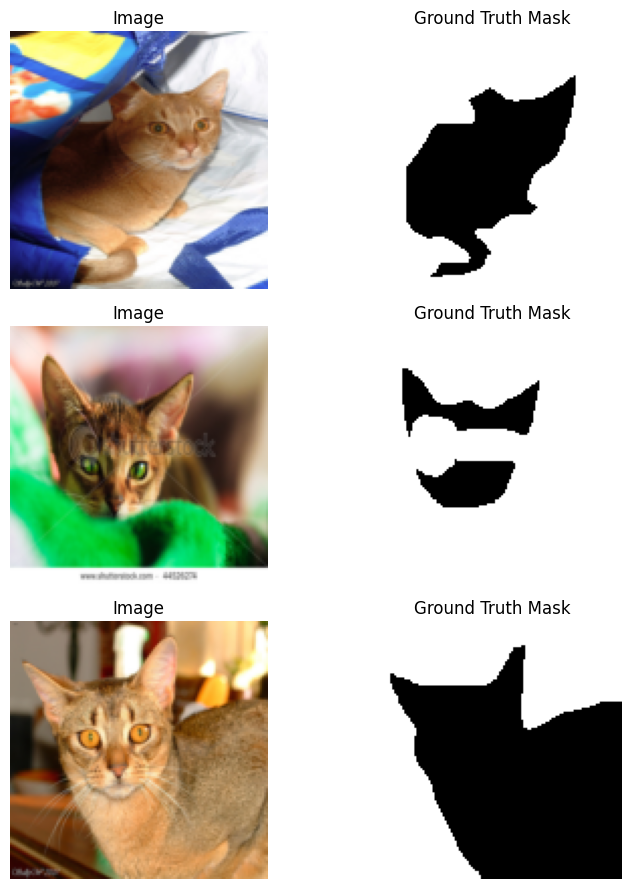


STAGE 1: coarse logarithmic lr sweep (fixed batch size)
Running LR sweep | lr=0.010000 | batch_size=32 | use_batchnorm=True


100%|██████████| 23/23 [00:07<00:00,  2.88it/s]


Epoch 1/15 | Train Loss: 0.4861 | Val Loss: 0.4670 | Val IoU: 0.7292 | Val F1: 0.8340


100%|██████████| 23/23 [00:08<00:00,  2.85it/s]


Epoch 2/15 | Train Loss: 0.4148 | Val Loss: 0.4206 | Val IoU: 0.7596 | Val F1: 0.8572


...

Epoch 14/15 | Train Loss: 0.1202 | Val Loss: 0.1690 | Val IoU: 0.9014 | Val F1: 0.9456


100%|██████████| 92/92 [00:08<00:00, 10.90it/s]


Epoch 15/15 | Train Loss: 0.1148 | Val Loss: 0.1648 | Val IoU: 0.9084 | Val F1: 0.9496
Testing best checkpoint...


100%|██████████| 459/459 [00:41<00:00, 11.11it/s]


Test Loss: 0.1741 | Test IoU: 0.9014 | Test F1: 0.9446


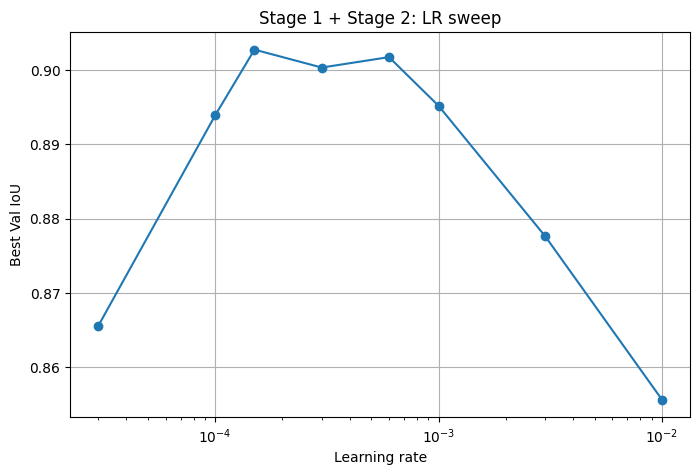

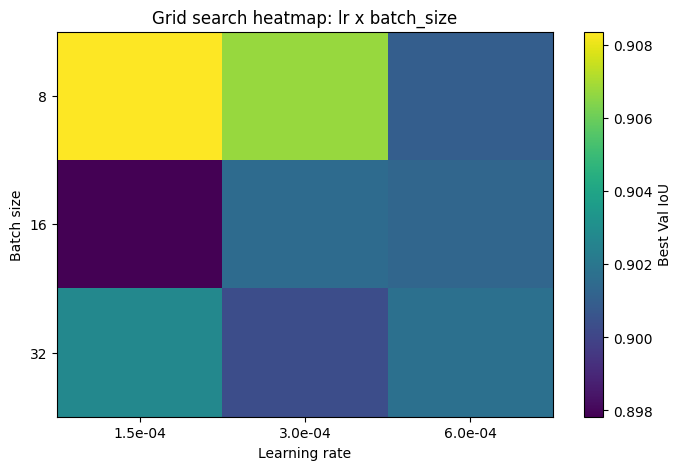

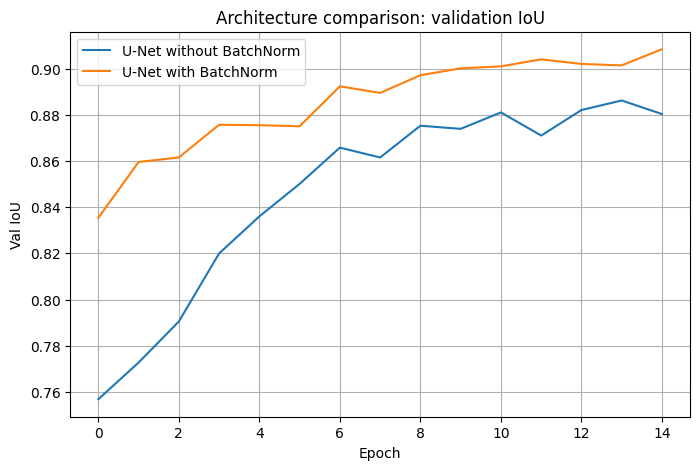

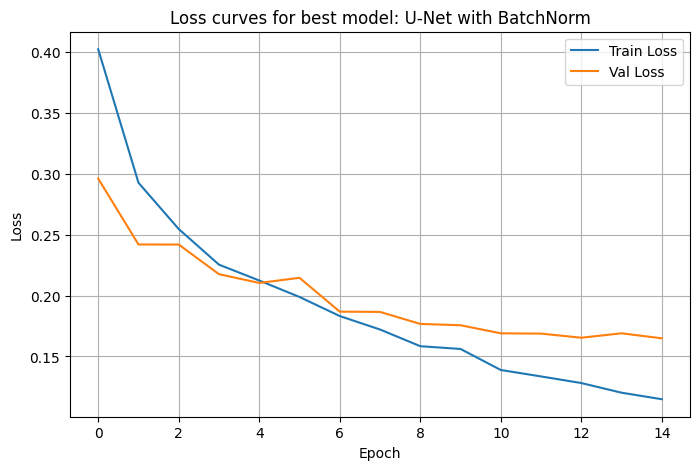


FINAL COMPARISON
Baseline best val IoU: 0.8862 | test IoU: 0.8777
BatchNorm best val IoU: 0.9084 | test IoU: 0.9014

Best model: U-Net with BatchNorm

Best hyperparameters from grid search: lr=0.000150, batch_size=8

Predicted segmentation examples from the best model:


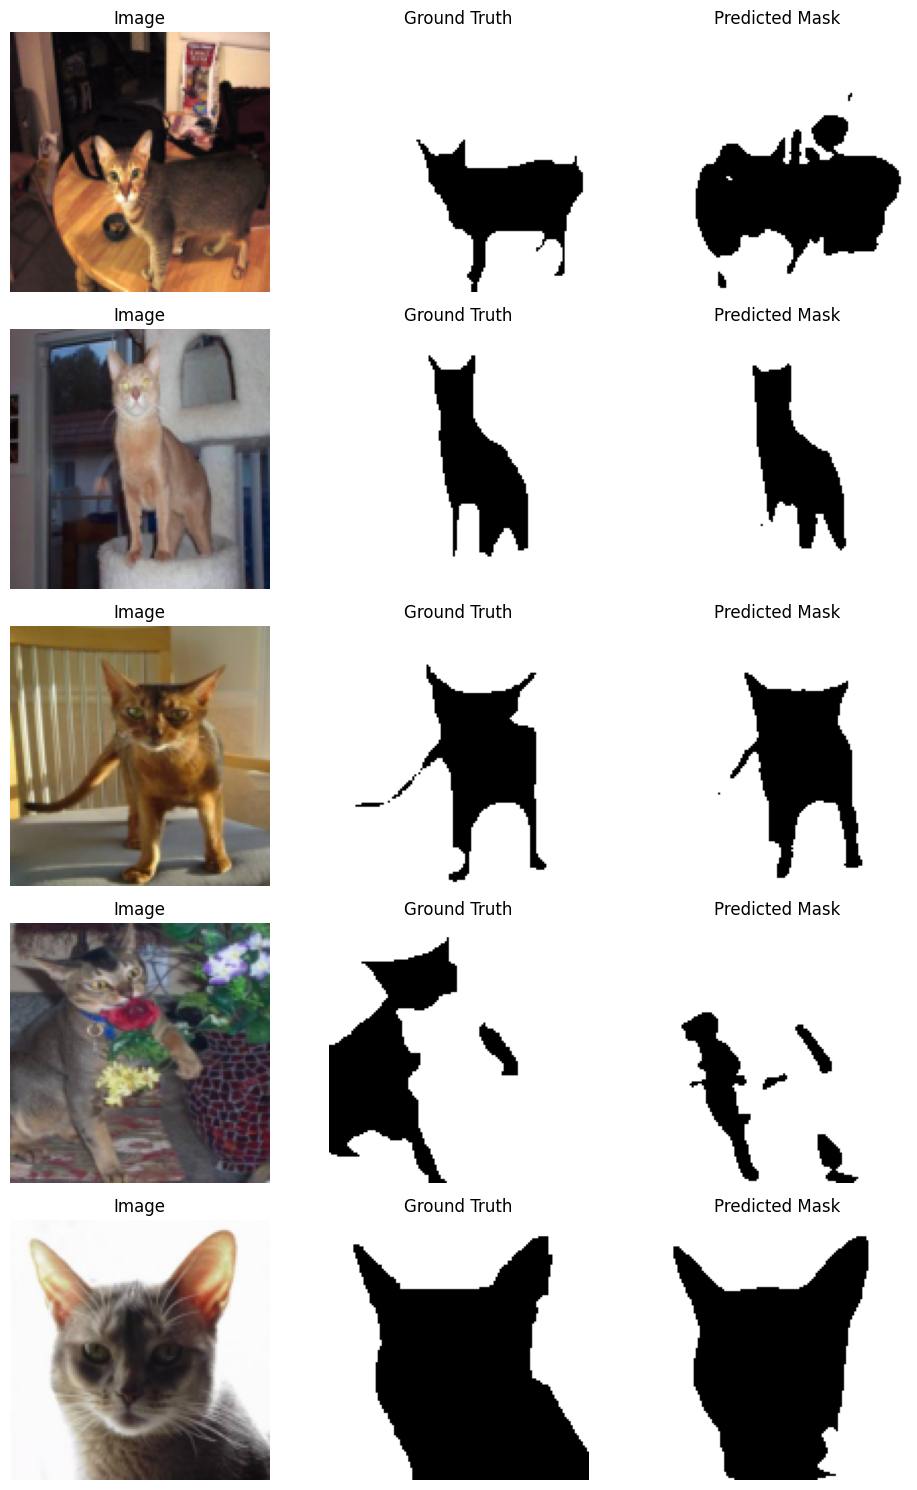

In [12]:
print("DATASET EXAMPLES")
plot_dataset_examples(config, n_samples=3)


stage1_lrs = config.sweep_lrs_stage1

print("\nSTAGE 1: coarse logarithmic lr sweep (fixed batch size)")
stage1_results = run_lr_sweep(
    base_cfg=config,
    lr_values=stage1_lrs,
    use_batchnorm=True
)

best_stage1 = pick_best_result(stage1_results)
lr_best_stage1 = best_stage1["lr"]

print("\nBest result from STAGE 1")
print(f"Best lr = {lr_best_stage1:.6f}")
print(f"Best val IoU = {best_stage1['best_val_iou']:.4f}")
print(f"Test IoU = {best_stage1['test_iou']:.4f}")
print(f"Test F1 = {best_stage1['test_f1']:.4f}")



stage2_lrs = sorted(set([
    max(lr_best_stage1 / 2, 1e-8),
    lr_best_stage1,
    lr_best_stage1 * 2
]))

print("\nSTAGE 2: local lr search around the best order")
print("Stage 2 lr candidates:", stage2_lrs)

stage2_results = run_lr_sweep(
    base_cfg=config,
    lr_values=stage2_lrs,
    use_batchnorm=True
)

best_stage2 = pick_best_result(stage2_results)
best_final_lr = best_stage2["lr"]

print("\nBest result from STAGE 2")
print(f"Best final lr = {best_final_lr:.6f}")
print(f"Best val IoU = {best_stage2['best_val_iou']:.4f}")
print(f"Test IoU = {best_stage2['test_iou']:.4f}")
print(f"Test F1 = {best_stage2['test_f1']:.4f}")



print("\nSTAGE 3: full 2D sweep over lr and batch_size")
grid_results = run_lr_bs_grid(
    base_cfg=config,
    lr_values=stage2_lrs,
    batch_sizes=config.sweep_batch_sizes,
    use_batchnorm=True
)

best_grid_result = pick_best_result(grid_results)
best_final_lr = best_grid_result["lr"]
best_final_bs = best_grid_result["batch_size"]

print("\nBest result from STAGE 3")
print(f"Best final lr = {best_final_lr:.6f}")
print(f"Best final batch_size = {best_final_bs}")
print(f"Best val IoU = {best_grid_result['best_val_iou']:.4f}")
print(f"Test IoU = {best_grid_result['test_iou']:.4f}")
print(f"Test F1 = {best_grid_result['test_f1']:.4f}")



print("\nARCHITECTURE COMPARISON ON BEST (lr, batch_size)")

baseline_cfg = build_cfg(
    config,
    learning_rate=best_final_lr,
    batch_size=best_final_bs,
    use_batchnorm=False
)

bn_cfg = build_cfg(
    config,
    learning_rate=best_final_lr,
    batch_size=best_final_bs,
    use_batchnorm=True
)

print("\nBaseline U-Net (without BatchNorm)")
baseline_trainer, baseline_history = run_single_experiment(baseline_cfg)

print("\nModified U-Net (with BatchNorm)")
bn_trainer, bn_history = run_single_experiment(bn_cfg)



all_lr_results = stage1_results + stage2_results
lr_df = pd.DataFrame([
    {
        "lr": r["lr"],
        "best_val_iou": r["best_val_iou"]
    }
    for r in all_lr_results
])
lr_df = lr_df.groupby("lr", as_index=False)["best_val_iou"].max().sort_values("lr")

plt.figure(figsize=(8, 5))
plt.plot(
    lr_df["lr"],
    lr_df["best_val_iou"],
    marker="o"
)
plt.xscale("log")
plt.xlabel("Learning rate")
plt.ylabel("Best Val IoU")
plt.title("Stage 1 + Stage 2: LR sweep")
plt.grid(True)
plt.show()


grid_df = pd.DataFrame([
    {
        "lr": r["lr"],
        "batch_size": r["batch_size"],
        "best_val_iou": r["best_val_iou"]
    }
    for r in grid_results
])

pivot = grid_df.pivot(index="batch_size", columns="lr", values="best_val_iou")
pivot = pivot.sort_index().sort_index(axis=1)

plt.figure(figsize=(8, 5))
plt.imshow(pivot.values, aspect="auto")
plt.colorbar(label="Best Val IoU")
plt.xticks(
    ticks=np.arange(len(pivot.columns)),
    labels=[f"{lr:.1e}" for lr in pivot.columns]
)
plt.yticks(
    ticks=np.arange(len(pivot.index)),
    labels=[str(bs) for bs in pivot.index]
)
plt.xlabel("Learning rate")
plt.ylabel("Batch size")
plt.title("Grid search heatmap: lr x batch_size")
plt.show()



plt.figure(figsize=(8, 5))
plt.plot(baseline_history["val_iou"], label="U-Net without BatchNorm")
plt.plot(bn_history["val_iou"], label="U-Net with BatchNorm")
plt.xlabel("Epoch")
plt.ylabel("Val IoU")
plt.title("Architecture comparison: validation IoU")
plt.legend()
plt.grid(True)
plt.show()


best_model_history = bn_history if bn_history["best_val_iou"] >= baseline_history["best_val_iou"] else baseline_history
best_model_trainer = bn_trainer if bn_history["best_val_iou"] >= baseline_history["best_val_iou"] else baseline_trainer
best_model_name = "U-Net with BatchNorm" if bn_history["best_val_iou"] >= baseline_history["best_val_iou"] else "U-Net without BatchNorm"

plt.figure(figsize=(8, 5))
plt.plot(best_model_history["train_loss"], label="Train Loss")
plt.plot(best_model_history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Loss curves for best model: {best_model_name}")
plt.legend()
plt.grid(True)
plt.show()


print("\nFINAL COMPARISON")
print(f"Baseline best val IoU: {baseline_history['best_val_iou']:.4f} | test IoU: {baseline_history['test_iou']:.4f}")
print(f"BatchNorm best val IoU: {bn_history['best_val_iou']:.4f} | test IoU: {bn_history['test_iou']:.4f}")

if bn_history["best_val_iou"] >= baseline_history["best_val_iou"]:
    print("\nBest model: U-Net with BatchNorm")
else:
    print("\nBest model: U-Net without BatchNorm")

print(f"\nBest hyperparameters from grid search: lr={best_final_lr:.6f}, batch_size={best_final_bs}")

print("\nPredicted segmentation examples from the best model:")
best_model_trainer.inference_and_plot_samples(n_samples=5)

было понятно по логам, что чисто гипотетически можно было ещё больше взять число эпох, но ноут итак долго крутился(